In [4]:
pip install xgboost imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 17.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')

# ---- FEATURE ENGINEERING ----
# Drop customerID — not a feature
df = df.drop('customerID', axis=1)

# Encode binary columns
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# Encode MultipleLines
df['MultipleLines'] = df['MultipleLines'].map(
    {'Yes': 1, 'No': 0, 'No phone service': 0})

# Encode internet service columns
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    df[col] = df[col].map(
        {'Yes': 1, 'No': 0, 'No internet service': 0})

# One hot encode remaining categoricals
df = pd.get_dummies(df, columns=['InternetService', 'Contract',
                                  'PaymentMethod'], drop_first=True)

# Drop tenure_group if exists
if 'tenure_group' in df.columns:
    df = df.drop('tenure_group', axis=1)

# Gender encode
df['gender'] = (df['gender'] == 'Male').astype(int)

print("Features shape:", df.shape)
print("Churn rate:", df['Churn'].mean())

# ---- TRAIN TEST SPLIT ----
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# ---- HANDLE IMBALANCE WITH SMOTE ----
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE - Train size: {X_train_sm.shape[0]}")
print(f"Churn distribution after SMOTE: {y_train_sm.value_counts().to_dict()}")

# ---- SCALE FEATURES ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# ---- TRAIN THREE MODELS ----
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auc': auc
    }
    print(f"\n{name} — AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

Features shape: (7032, 24)
Churn rate: 0.26578498293515357

Train size: 5625
Test size: 1407

After SMOTE - Train size: 8260
Churn distribution after SMOTE: {0: 4130, 1: 4130}

Logistic Regression — AUC: 0.8105
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.55      0.63      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407


Random Forest — AUC: 0.8057
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1033
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407


XGBoost — AUC: 0.8002
              precision    recall  f1-score   support

           0       0.86     

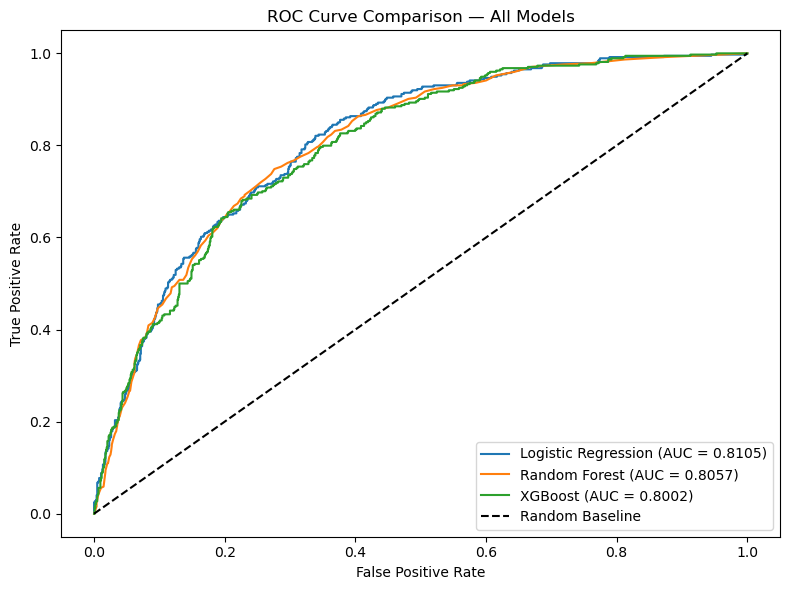

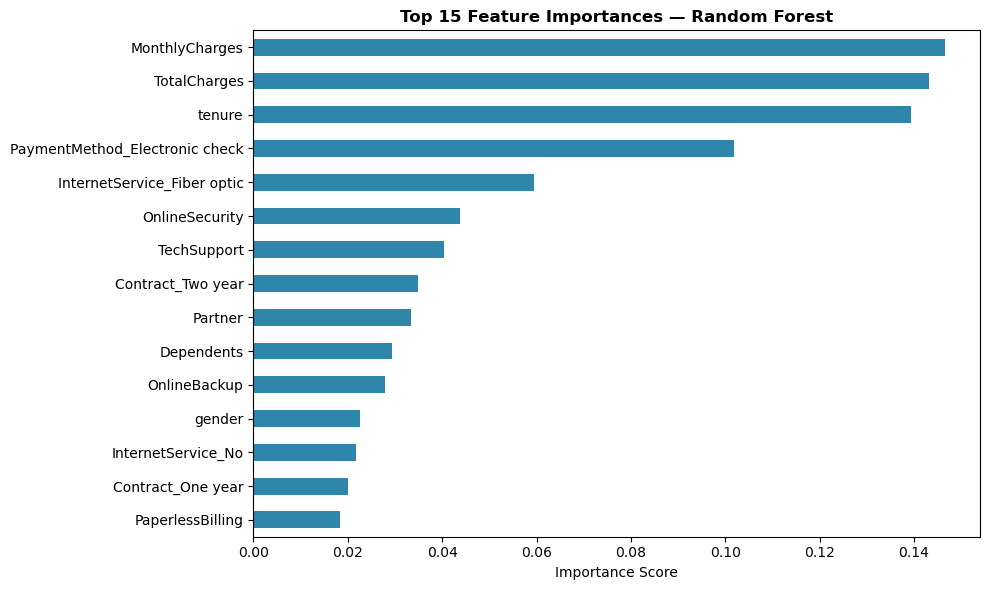

Top 15 features driving churn:
MonthlyCharges                    0.146632
TotalCharges                      0.143161
tenure                            0.139258
PaymentMethod_Electronic check    0.101828
InternetService_Fiber optic       0.059493
OnlineSecurity                    0.043763
TechSupport                       0.040299
Contract_Two year                 0.034843
Partner                           0.033465
Dependents                        0.029281
OnlineBackup                      0.027794
gender                            0.022624
InternetService_No                0.021730
Contract_One year                 0.020099
PaperlessBilling                  0.018463
dtype: float64


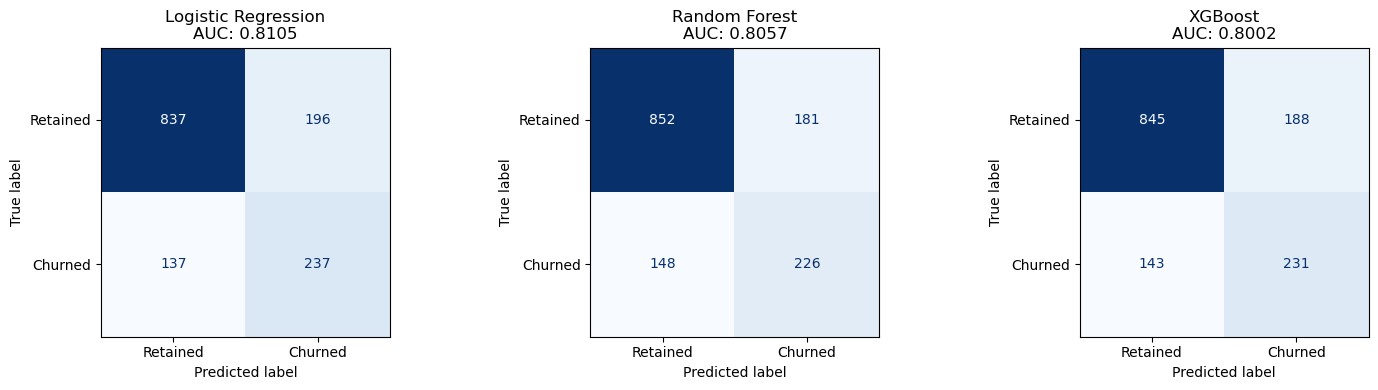


Model Comparison Summary:
              Model    AUC  Accuracy  Churn Precision  Churn Recall  Churn F1
Logistic Regression 0.8105    0.7633           0.5473        0.6337    0.5874
      Random Forest 0.8057    0.7662           0.5553        0.6043    0.5787
            XGBoost 0.8002    0.7647           0.5513        0.6176    0.5826


In [6]:
# ---- ROC CURVES — ALL 3 MODELS ----
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})")

plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/03_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- FEATURE IMPORTANCE — RANDOM FOREST ----
feature_names = X.columns.tolist()
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='#2E86AB')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../visuals/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 features driving churn:")
print(top_features)

# ---- CONFUSION MATRIX — BEST MODEL (Logistic Regression) ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained','Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC: {res["auc"]:.4f}')
plt.tight_layout()
plt.savefig('../visuals/05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- MODEL SUMMARY TABLE ----
summary = []
for name, res in results.items():
    report = classification_report(y_test, res['y_pred'], output_dict=True)
    summary.append({
        'Model': name,
        'AUC': round(res['auc'], 4),
        'Accuracy': round(report['accuracy'], 4),
        'Churn Precision': round(report['1']['precision'], 4),
        'Churn Recall': round(report['1']['recall'], 4),
        'Churn F1': round(report['1']['f1-score'], 4)
    })

summary_df = pd.DataFrame(summary)
print("\nModel Comparison Summary:")
print(summary_df.to_string(index=False))